In [6]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)



In [ ]:
#Make a copy of dataframe first
df_locations = df.copy()
# Explore job location and count each job location 
df_locations = df_locations.explode('job_location')
location_counts = df_locations.groupby('job_location').size()
df_location_counts = location_counts.reset_index(name = 'location_counts')
df_location_counts.sort_values(by='location_counts', ascending=False, inplace=True)
df_location_counts


,job_location,location_counts
607,Anywhere,69552
14051,Singapore,23415
11529,"Paris, France",12311
1543,"Bengaluru, Karnataka, India",11474
8855,"London, UK",10564
...,...,...
8046,"La Chaussée, France",1
8052,"La Compañia, Oaxaca, Mexico",1
8054,"La Crescent, MN",1
8059,"La Estrella, Antioquia, Colombia",1


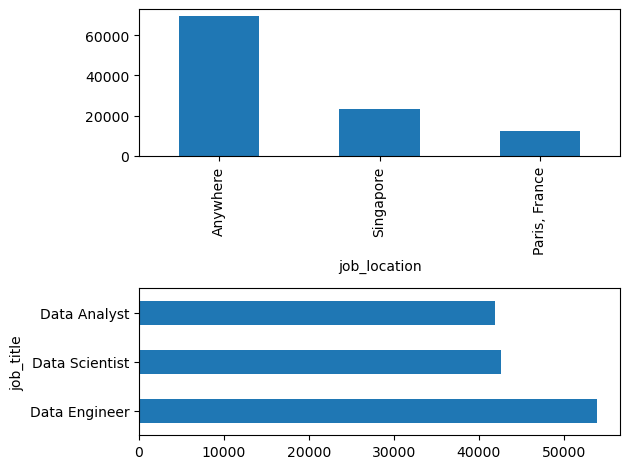

In [5]:
fig, ax = plt.subplots(2,1)

df['job_location'].value_counts().head(3).plot(kind='bar', ax=ax[0])
df['job_title'].value_counts().head(3).plot(kind='barh', ax=ax[1])

fig.tight_layout()

In [30]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

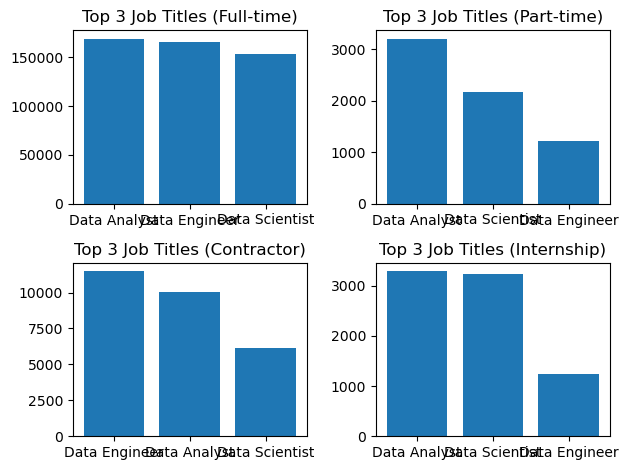

In [29]:
#Create a bar chart
fig, ax = plt.subplots(2,2)

#Make a list of schedule types
schedules = ['Full-time', 'Part-time', 'Contractor', 'Internship']

#Loop through each job_schedule_type and filter the dataframe

for i, schedule in enumerate(schedules):
    df_schedule = df[df['job_schedule_type'] == schedule]
    job_titles = df_schedule['job_title_short'].value_counts().head(3)
    ax[i//2, i%2].bar(job_titles.index, job_titles.values)
    ax[i//2, i%2].set_title(f'Top 3 Job Titles ({schedule})')

fig.tight_layout()
plt.show()

In [35]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

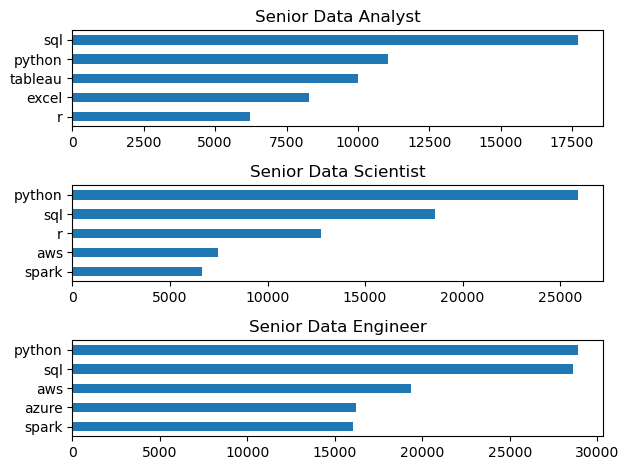

In [45]:
#count top skills for each job_title
df_skills = df.copy()
#to transform each element of a list-like column into a separate row
df_skills = df_skills.explode('job_skills')
#Count each skill required for each job_title_short
skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()
#Create a new column named 'Skill count'
df_skills_count = skills_count.reset_index(name='skill_count')
df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)

#Create a bar chart
fig, ax = plt.subplots(3,1)

#Make a list of job roles
job_roles = ['Senior Data Analyst', 'Senior Data Scientist', 'Senior Data Engineer']

#Loop through each job_schedule_type and filter the dataframe
for i, role in enumerate(job_roles):
    df_plot = df_skills_count[df_skills_count['job_title_short']== role].head(5)
    df_plot.plot(kind='barh', x='job_skills', y='skill_count', ax=ax[i], title=role)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)

fig.tight_layout()
plt.show()

In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

/opt/anaconda3/envs/python_course/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


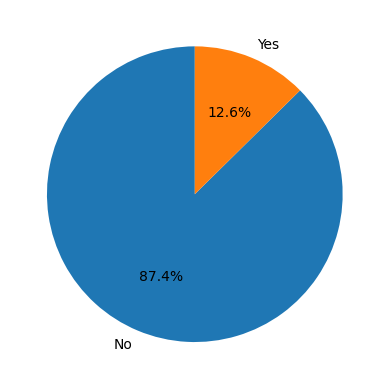

In [ ]:
df_DA = df[df['job_title_short']=='Data Analyst'].copy()
job_insurance_count = df_DA['job_health_insurance'].value_counts()
plt.pie(job_insurance_count, labels=['No', 'Yes'], autopct='%1.1f%%', startangle=90)
plt.show()

In [2]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

/opt/anaconda3/envs/python_course/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


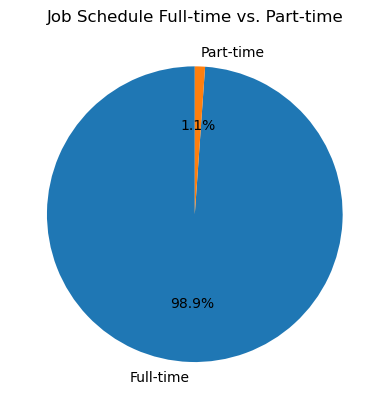

In [ ]:
#Create dataframe that filter out and contain either job with Full-time and Part-time
df_ft_pt = df[df['job_schedule_type'].isin(['Full-time', 'Part-time'])].copy()
#Count the number of jobs with Full-time and Part-time
job_ft_pt_count = df_ft_pt['job_schedule_type'].value_counts()
job_ft_pt_count
#Create a pie chart
plt.pie(job_ft_pt_count, labels=job_ft_pt_count.index, startangle=90, autopct='%1.1f%%')
plt.title('Job Schedule Full-time vs. Part-time')
plt.show()

In [6]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

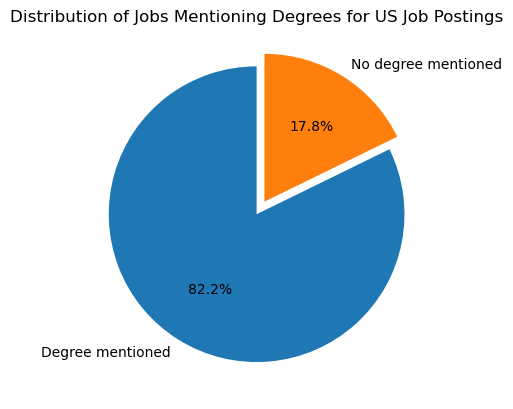

In [9]:
#Create dataframe that contains only jobs from the US
df_US = df[df['job_country']=='United States']

#Count number of jobs with no degree mentioned
job_no_degree_counts = df_US['job_no_degree_mention'].value_counts()

#Create pie plot for this
plt.pie(job_no_degree_counts, labels= ['Degree mentioned', 'No degree mentioned'], explode=[0,0.1], startangle=90, autopct='%1.1f%%')
plt.title('Distribution of Jobs Mentioning Degrees for US Job Postings')
plt.show()

In [6]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

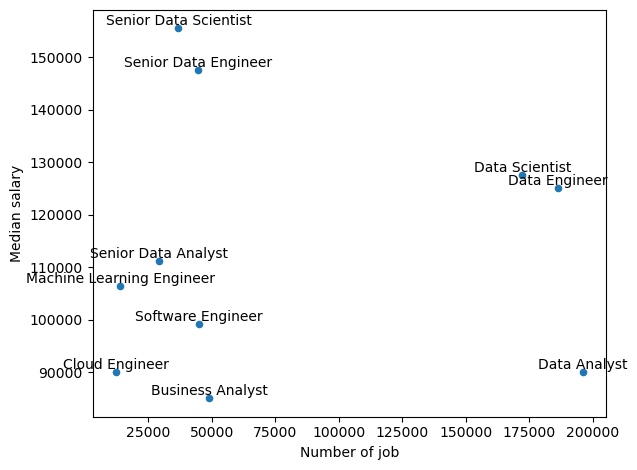

In [7]:
#create dataframe that explode the job_title short
df_exploded = df.explode('job_title_short')

#creat dataframe name job_stats that contain median salary of each job_title_short and then sort them in order
job_stats = df_exploded.groupby('job_title_short').agg(
    job_count = ('job_title_short', 'count'), median_salary = ('salary_year_avg', 'median')
)
job_stats.sort_values(by='job_count', ascending=False).head(10)

#plot scatter plot
job_stats.plot(kind='scatter', x='job_count', y='median_salary')
plt.xlabel('Number of job')
plt.ylabel('Median salary')
plt.tight_layout()

#Add data label to each point
for i in range(len(job_stats)):
    job_count = job_stats['job_count'].iloc[i]
    mean_salary = job_stats['median_salary'].iloc[i]
    job_title = job_stats.index[i]
    plt.text(job_count, mean_salary, job_title, ha='center', va='bottom')

plt.show()

In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

/opt/anaconda3/envs/python_course/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


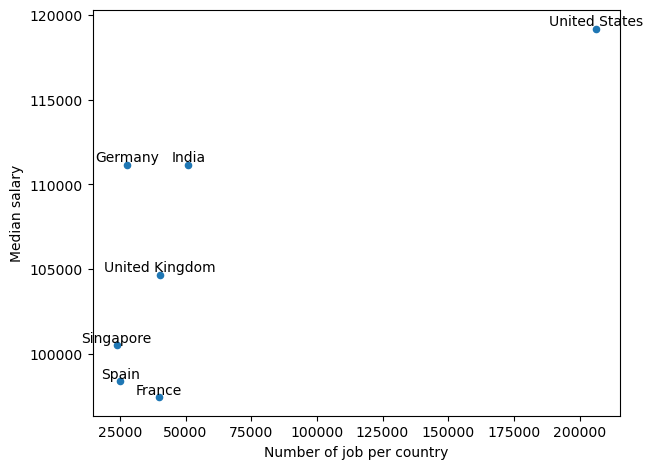

In [ ]:
#create dataframe that explode the job_country
df_exploded = df.explode('job_country')

#creat dataframe name job_stats that contain median salary of each job_country and then sort them in order
job_country_stats = df_exploded.groupby('job_country').agg(
    country_count = ('job_country', 'count'), median_salary = ('salary_year_avg', 'median')
)
country_stats = job_country_stats.sort_values(by='country_count', ascending=False).head(7)

#plot scatter plot
country_stats.plot(kind='scatter', x='country_count', y='median_salary')
plt.xlabel('Number of job per country')
plt.ylabel('Median salary')
plt.tight_layout()

#Add data label to each point
for i in range(len(country_stats)):
    country_count = country_stats['country_count'].iloc[i]
    mean_salary = country_stats['median_salary'].iloc[i]
    job_title = country_stats.index[i]
    plt.text(country_count, mean_salary, job_title, ha='center', va='bottom')

plt.show()

In [9]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

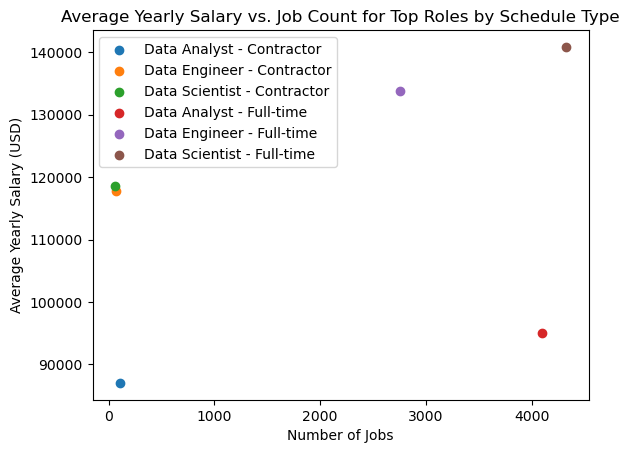

In [13]:
#Define jobs specific to include
target_job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']

#Filter US job for only full-time and part-time roles and target job titles, then drops rows with missing salary data
us_job_df = df[
    (df['job_country']=='United States') &
    (df['job_schedule_type'].isin(['Full-time', 'Contractor']))&
    (df['job_title_short'].isin(target_job_titles))
].dropna(subset=['salary_year_avg']).copy()

#Group by job schedule type and job title, create mean salary and job count
stats = us_job_df.groupby(['job_schedule_type', 'job_title_short']).agg(
    mean_salary_year_avg=('salary_year_avg', 'mean'),
    job_count=('job_title_short', 'count')
).dropna()

# Reset the index to make plotting easier
stats.reset_index(inplace=True)

#combine title and type into 1 value for label
stats['job_title_type'] = stats['job_title_short'] + ' - ' + stats['job_schedule_type'] 

#plot graph
for job_title_type in stats['job_title_type'].unique():
    subset = stats[stats['job_title_type']==job_title_type]
    plt.scatter(subset['job_count'], subset['mean_salary_year_avg'], label=job_title_type)

plt.xlabel('Number of Jobs')
plt.ylabel('Average Yearly Salary (USD)')
plt.title('Average Yearly Salary vs. Job Count for Top Roles by Schedule Type')
plt.legend()
plt.show()

In [12]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

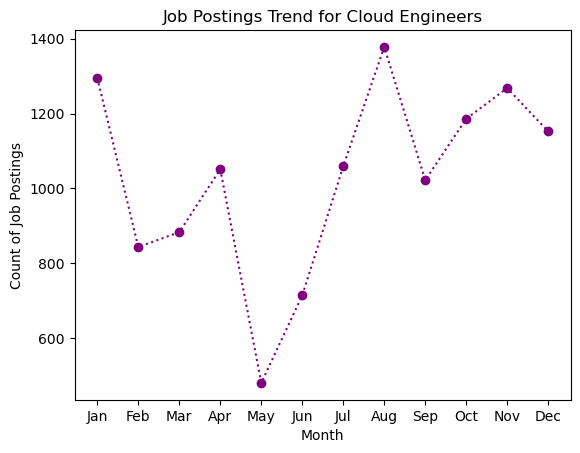

In [ ]:
#Create dataframe containing only the job as 'Cloud Engineer)
df_ce = df[df['job_title_short']=='Cloud Engineer'].copy()

#Use month name for plotting
df_ce['job_posted_month'] = df_ce['job_posted_date'].dt.month
df_ce = df_ce.sort_values('job_posted_month')

# Group and sort
monthly_counts = (df_ce.groupby('job_posted_month').size().sort_index())

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

#plot line chart
plt.plot(monthly_counts.index, monthly_counts.values, linestyle = ':', color = 'purple', marker = 'o')
plt.xticks(range(1,13), month_labels)
plt.xlabel('Month')
plt.ylabel('Count of Job Postings')
plt.title('Job Postings Trend for Cloud Engineers')

plt.show()

In [2]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

/opt/anaconda3/envs/python_course/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


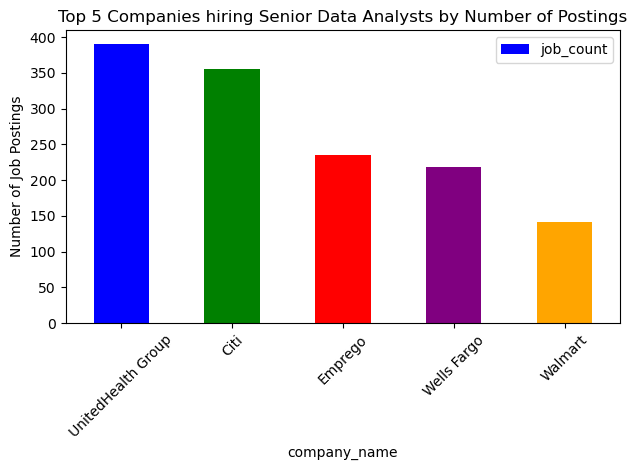

In [9]:
#Filter for Senior Data Analyst role
df_sda = df[df['job_title_short']=='Senior Data Analyst']

#Get top 5 companies by number of job posting
top_companies = (df_sda['company_name'].value_counts().head(5).reset_index())

#Rename column
top_companies.columns = ['company_name', 'job_count']

# Define 5 different colors
colors = ['blue', 'green', 'red', 'purple', 'orange']

#Plot bar chart
top_companies.plot(kind='bar', x= 'company_name', y= 'job_count', color=colors)
plt.ylabel('Number of Job Postings')
plt.title('Top 5 Companies hiring Senior Data Analysts by Number of Postings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [10]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

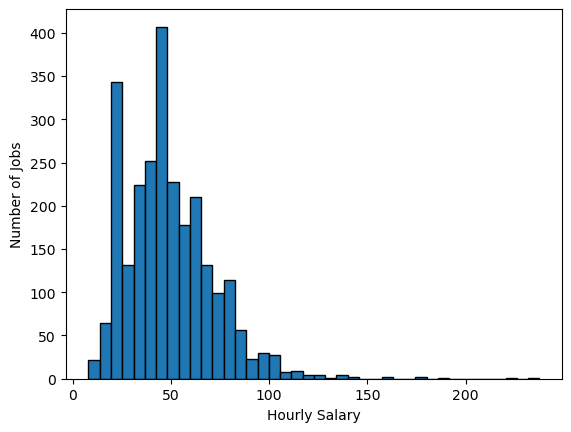

In [11]:
#Create dataframe containing only the job as 'Data Scientist)
df_DS = df[df['job_title_short']=='Data Scientist'].copy()

#create scatter plot
df_DS['salary_hour_avg'].plot(kind = 'hist', bins = 40, edgecolor = 'black')
plt.xlabel('Hourly Salary')
plt.ylabel('Number of Jobs')
plt.show()

In [12]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

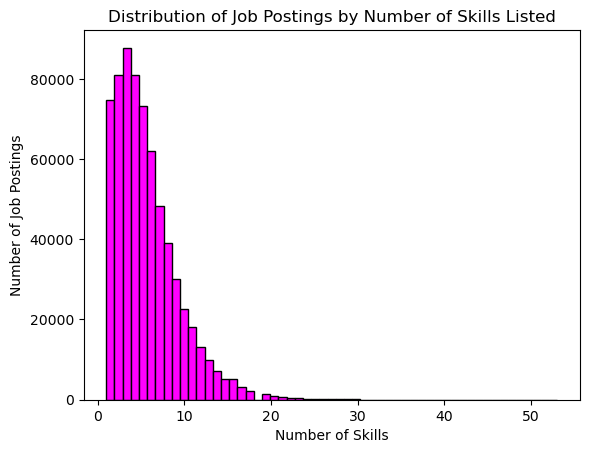

In [16]:
#Create data set with Job skills without null
df_skills = df[df['job_skills'].notna()].copy()
df_skills['num_skills'] = df_skills['job_skills'].apply(len)

#Create scatter plot
df_skills['num_skills'].plot(kind = 'hist', bins = 55, color = 'magenta', edgecolor ='black')
plt.title('Distribution of Job Postings by Number of Skills Listed')
plt.xlabel('Number of Skills')
plt.ylabel('Number of Job Postings')
plt.show()

In [20]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

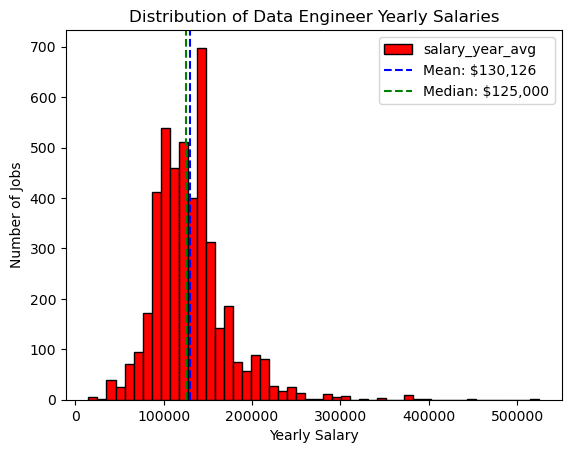

In [22]:
#Create Dataframe containing only Data Engineer job
df_DE = df[df['job_title_short']=='Data Engineer'].copy()

#Create mean and median year salary
mean_salary = df_DE['salary_year_avg'].mean()
median_salary = df_DE['salary_year_avg'].median()

# Create Scatter plot
df_DE['salary_year_avg'].plot(kind = 'hist', bins = 50, color = 'red', edgecolor = 'black')
plt.xlabel('Yearly Salary')
plt.ylabel('Number of Jobs')

#Create mean salary line
plt.axvline(
    x=mean_salary,
    color='blue',
    linestyle='dashed',
    label=f'Mean: ${mean_salary:,.0f}'
)

#Create median salary line
plt.axvline(
    x=median_salary,
    color='green',
    linestyle='dashed',
    label=f'Median: ${median_salary:,.0f}'
)

plt.title('Distribution of Data Engineer Yearly Salaries')
plt.legend()
plt.show()


In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)



/opt/anaconda3/envs/python_course/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Text(0.5, 0, 'Data Scientist')

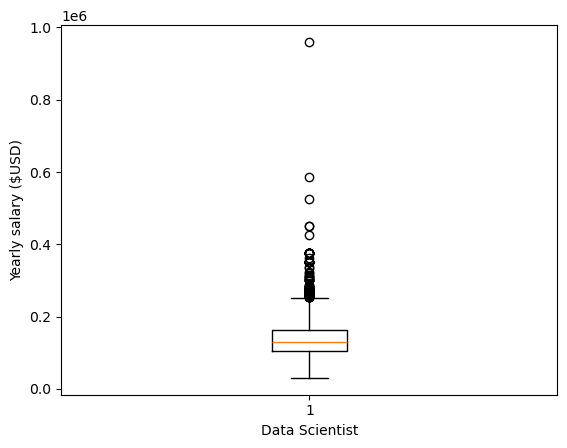

In [3]:

#Only get the Data scientist job in the US
df_DS_US = df[(df['job_title_short'] == 'Data Scientist') & (df['job_country'] == 'United States')].copy()

#Drop NaN value from the column to plot
df_DS_US = df_DS_US.dropna(subset=['salary_year_avg'])

plt.boxplot(df_DS_US['salary_year_avg'])
plt.ylabel('Yearly salary ($USD)')
plt.xlabel('Data Scientist')

In [4]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

/var/folders/nq/95kssw8163g2tt33czq7h5p8px4pb7/T/ipykernel_2605/3163970114.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([country_df['salary_hour_avg'].dropna() for country_df in df_DA_list],


(0.0, 150.0)

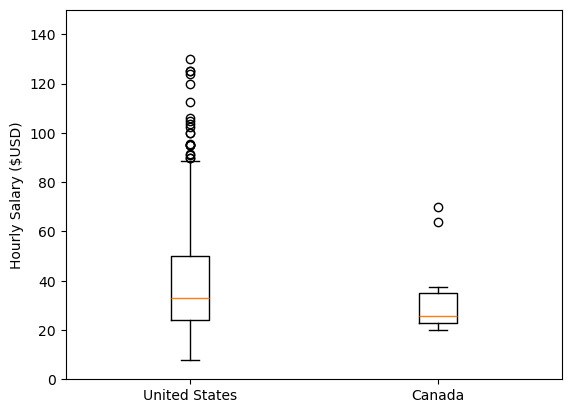

In [16]:
#Only get the Data Analyst job in the US and Canada
df_DA = df[(df['job_title_short'] == 'Data Analyst')]

#Create list of 2 countries
countries = ['United States', 'Canada']

#Filter Data Analyst from 2 countries in the list
df_DA_list = [df_DA[df_DA['job_country'] == country] for country in countries]

#create box plot
plt.boxplot([country_df['salary_hour_avg'].dropna() for country_df in df_DA_list],
    labels=countries)
plt.ylabel('Hourly Salary ($USD)')
plt.ylim(0, 150)


In [2]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

/opt/anaconda3/envs/python_course/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


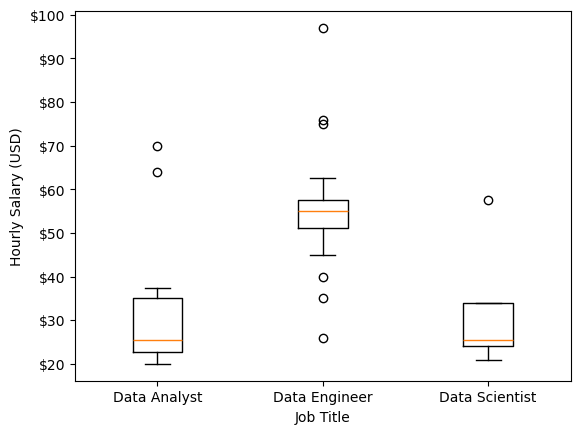

In [4]:
#Create dataframe containing job in Canada
df_CA = df[df['job_country'] == 'Canada'].copy()

#Create list of 3 job titles
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

#Create a sub-dataframe from each job titles
df_CA_list = [df_CA[df_CA['job_title_short'] == job_title] for job_title in job_titles]

#Get the salary data from each sub-dataframe
salary_data = [job_title_df['salary_hour_avg'].dropna() for job_title_df in df_CA_list]

#Import Funcformatter to add $ before the number
from matplotlib.ticker import FuncFormatter
#ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:,.0f}'))

#Create figure and ax
fig, ax = plt.subplots()

#Create boxplot
ax.boxplot(salary_data, tick_labels=job_titles)

#Add label
ax.set_xlabel('Job Title')
ax.set_ylabel('Hourly Salary (USD)')

# Add $ to y-axis
from matplotlib.ticker import FuncFormatter
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:,.0f}'))


plt.show()

